In [ ]:
%%capture

!pip install torch torchvision torchaudio
!pip install segmentation-models-pytorch timm
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import os
import zipfile
import random
import json
from pathlib import Path
from tqdm import tqdm

> Seeding

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Import Dataset

- Unzip dataset

In [ ]:
file_id = '112oBow9f_rmAaH0LAFFsRwD5Oz23e2Cd'
output_zip = '/content/dataset.zip'
extract_path = '/content/flopwd_data'

In [ ]:
!gdown --id {file_id} -O {output_zip}

if os.path.exists(output_zip):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(output_zip, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Success! Dataset extracted to {extract_path}")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=112oBow9f_rmAaH0LAFFsRwD5Oz23e2Cd
From (redirected): https://drive.google.com/uc?id=112oBow9f_rmAaH0LAFFsRwD5Oz23e2Cd&confirm=t&uuid=4a5a28e2-9a5e-4ab1-9e85-acd7095f1e29
To: /content/dataset.zip
100% 358M/358M [00:04<00:00, 89.3MB/s]
Success! Dataset extracted to /content/flopwd_data


- Get Images

In [ ]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")

In [ ]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [ ]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [ ]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [ ]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


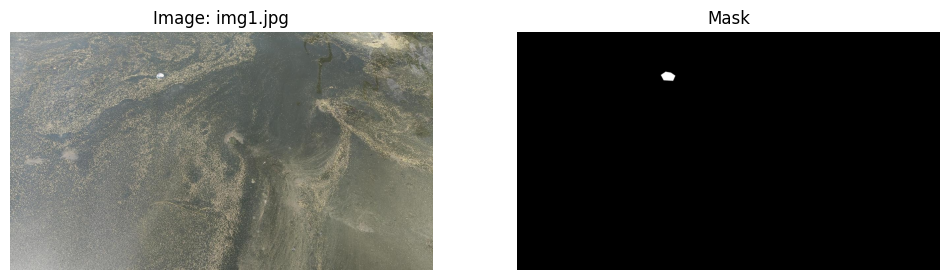

In [ ]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Data Splitting (70:15:15)

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["has_plastic"]
)

In [ ]:
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=15/85,
    random_state=42,
    stratify=train_val_df["has_plastic"]
)

In [ ]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1400
Val  : 301
Test : 301


## Data Preprocessing

### Image Augmentation

In [ ]:
IMAGE_HEIGHT = 448
IMAGE_WIDTH = 800

In [ ]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [ ]:
# transform only training and validation images

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=1, sigma=50, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 8),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        p=0.3
    ),
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Image Preprocessing (Class & Dataloader)

In [ ]:
class Dataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32) # changes from 0/255 into 0.0/1.0 (0=background, 1=plastic)

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    mask = mask.unsqueeze(0) # add channel [1, H, W]

    return image, mask

In [ ]:
train_dataset = Dataset(train_df, transforms=train_transform)
val_dataset = Dataset(val_df, transforms=val_transform)
test_dataset = Dataset(test_df, transforms=val_transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

## Modelling

In [ ]:
%%capture

model = smp.Unet(
    encoder_name="tu-convnextv2_tiny.fcmae_ft_in22k_in1k",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

## Training

#### Training Hyperparameter

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cuda'

In [ ]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handlign

For Give more loss if positive pixel are predicted falsely (FP)

In [ ]:
pos_pixels = 0
neg_pixels = 0

# step 1: sampling sebanyak 200
subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(18.368890673898054)

##### BCE

Loss function for Clasification per pixel

In [ ]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=DEVICE)
)

##### DICE

Loss function for Mask Overlapping

In [ ]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

#####  Combine

In [ ]:
def combined_loss(pred_mask, true_mask, dice_weight=0.6, bce_weight=0.4):
    d_loss = dice_loss(pred_mask, true_mask)
    b_loss = bce_loss(pred_mask, true_mask)
    return (dice_weight * d_loss) + (bce_weight * b_loss)

#### Optimizer

In [ ]:
encoder_params = list(model.encoder.parameters())
decoder_params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())

optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": 1e-5},
    {"params": decoder_params, "lr": 3e-4},
], weight_decay=1e-4)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_12083/2321429026.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


#### Metric

In [ ]:
def apply_sigmoid(x):
  return torch.sigmoid(x)

In [ ]:
def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()

In [ ]:
def compute_stats(preds, targets, eps=1e-7):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1,2,3))
  fp = (preds * (1 - targets)).sum(dim=(1,2,3))
  fn = ((1 - preds) * targets).sum(dim=(1,2,3))

  iou = (tp + eps) / (tp + fp + fn + eps)
  dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  precision = (tp + eps) / (tp + fp + eps)
  recall = (tp + eps) / (tp + fn + eps)

  return {
      "iou": iou.mean().item(),
      "dice": dice.mean().item(),
      "precision": precision.mean().item(),
      "recall": recall.mean().item()
  }

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Training", leave=False)

    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = combined_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [ ]:
def validate_one_epoch(model, loader, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    iou_scores = []
    dice_scores = []
    precision_scores = []
    recall_scores = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)
            loss = combined_loss(logits, masks)

            probs = apply_sigmoid(logits)
            preds = binarize_mask(probs, threshold=threshold)

            stats = compute_stats(preds, masks)

            running_loss += loss.item()
            iou_scores.append(stats["iou"])
            dice_scores.append(stats["dice"])
            precision_scores.append(stats["precision"])
            recall_scores.append(stats["recall"])

    return {
        "loss": running_loss / len(loader),
        "iou": np.mean(iou_scores),
        "dice": np.mean(dice_scores),
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores)
    }

In [ ]:
def find_best_threshold(model, loader, device):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.5
    best_dice = -1

    model.eval()

    all_probs = []
    all_masks = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Collecting val probs", leave=False):
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu()
            all_probs.append(probs)
            all_masks.append(masks.cpu())

    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    for threshold in thresholds:
        preds = (all_probs > threshold).float()
        stats = compute_stats(preds, all_masks)
        if stats["dice"] > best_dice:
            best_dice = stats["dice"]
            best_threshold = threshold

    return best_threshold, best_dice

#### Training

In [ ]:
EPOCHS = 30
PATIENCES = 5

In [ ]:
best_val_dice = -1
best_model_path = "/content/best_flopwd_unetplusplus.pth"

history = []
counter = 0

In [ ]:
for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)

    best_threshold, _ = find_best_threshold(model, val_loader, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, DEVICE, threshold=best_threshold)

    print(f"Train Loss   : {train_loss:.4f}")
    print(f"Val Loss     : {val_metrics['loss']:.4f}")
    print(f"Val IoU      : {val_metrics['iou']:.4f}")
    print(f"Val Dice     : {val_metrics['dice']:.4f}")
    print(f"Val Precision: {val_metrics['precision']:.4f}")
    print(f"Val Recall   : {val_metrics['recall']:.4f}")
    print(f"Best Threshold: {best_threshold:.2f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_iou": val_metrics["iou"],
        "val_dice": val_metrics["dice"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "best_threshold": float(best_threshold)
    })

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")
        counter = 0
    else:
        counter += 1
        print(f"No improvement. Patience counter: {counter}/{PATIENCES}")

    if counter >= PATIENCES:
        print("Early stopping triggered.")
        break


Epoch [1/30]


Training:   0%|          | 0/350 [00:00<?, ?it/s]/tmp/ipykernel_12083/2539086823.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Train Loss   : 0.6382
Val Loss     : 0.4982
Val IoU      : 0.4821
Val Dice     : 0.5812
Val Precision: 0.6410
Val Recall   : 0.7136
Best Threshold: 0.85
Best model saved.

Epoch [2/30]


Train Loss   : 0.4696
Val Loss     : 0.3956
Val IoU      : 0.5430
Val Dice     : 0.6440
Val Precision: 0.6910
Val Recall   : 0.7458
Best Threshold: 0.85
Best model saved.

Epoch [3/30]


Train Loss   : 0.3951
Val Loss     : 0.3593
Val IoU      : 0.5604
Val Dice     : 0.6625
Val Precision: 0.6880
Val Recall   : 0.7851
Best Threshold: 0.90
Best model saved.

Epoch [4/30]


...

Train Loss   : 0.2229
Val Loss     : 0.2836
Val IoU      : 0.6528
Val Dice     : 0.7503
Val Precision: 0.7271
Val Recall   : 0.8774
Best Threshold: 0.90
No improvement. Patience counter: 1/5

Epoch [22/30]


Train Loss   : 0.2126
Val Loss     : 0.2833
Val IoU      : 0.6602
Val Dice     : 0.7542
Val Precision: 0.7995
Val Recall   : 0.8021
Best Threshold: 0.85
No improvement. Patience counter: 2/5

Epoch [23/30]


Train Loss   : 0.2274
Val Loss     : 0.2784
Val IoU      : 0.6723
Val Dice     : 0.7655
Val Precision: 0.7790
Val Recall   : 0.8412
Best Threshold: 0.80
No improvement. Patience counter: 3/5

Epoch [24/30]


Train Loss   : 0.2114
Val Loss     : 0.2714
Val IoU      : 0.6722
Val Dice     : 0.7650
Val Precision: 0.7715
Val Recall   : 0.8505
Best Threshold: 0.85
No improvement. Patience counter: 4/5

Epoch [25/30]


Train Loss   : 0.2127
Val Loss     : 0.2807
Val IoU      : 0.6640
Val Dice     : 0.7568
Val Precision: 0.7649
Val Recall   : 0.8474
Best Threshold: 0.80
No improvement. Patience counter: 5/5
Early stopping triggered.


##### Training History

In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv("/content/flopwd_training_history.csv", index=False)
history_df.tail()

,epoch,train_loss,val_loss,val_iou,val_dice,val_precision,val_recall,best_threshold
20,21,0.222933,0.283568,0.652761,0.750299,0.727097,0.877379,0.90
21,22,0.212568,0.283266,0.660196,0.754250,0.799548,0.802114,0.85
22,23,0.227351,0.278364,0.672256,0.765471,0.779045,0.841188,0.80
23,24,0.211448,0.271386,0.672207,0.765036,0.771538,0.850528,0.85
24,25,0.212710,0.280739,0.664035,0.756829,0.764892,0.847391,0.80


##### Best Model

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

<All keys matched successfully>

##### Best Threshold

In [ ]:
best_threshold, best_dice = find_best_threshold(model, val_loader, DEVICE)

#### Evaluation

In [ ]:
test_metrics = validate_one_epoch(model, test_loader, DEVICE, threshold=best_threshold)

for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

loss: 0.2884
iou: 0.6528
dice: 0.7476
precision: 0.7814
recall: 0.8104


- Result

In [ ]:
with open("/content/flopwd_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

## Inferences

In [ ]:
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)
    return image

def show_predictions(model, dataset, device, threshold=0.5, num_samples=5):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = torch.sigmoid(logits)
            pred = (probs > threshold).float()

            image_np = denormalize_image(image, mean, std)
            mask_np = mask.squeeze(0).cpu().numpy()
            pred_np = pred.squeeze().cpu().numpy()

            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image_np)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(mask_np, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_np, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

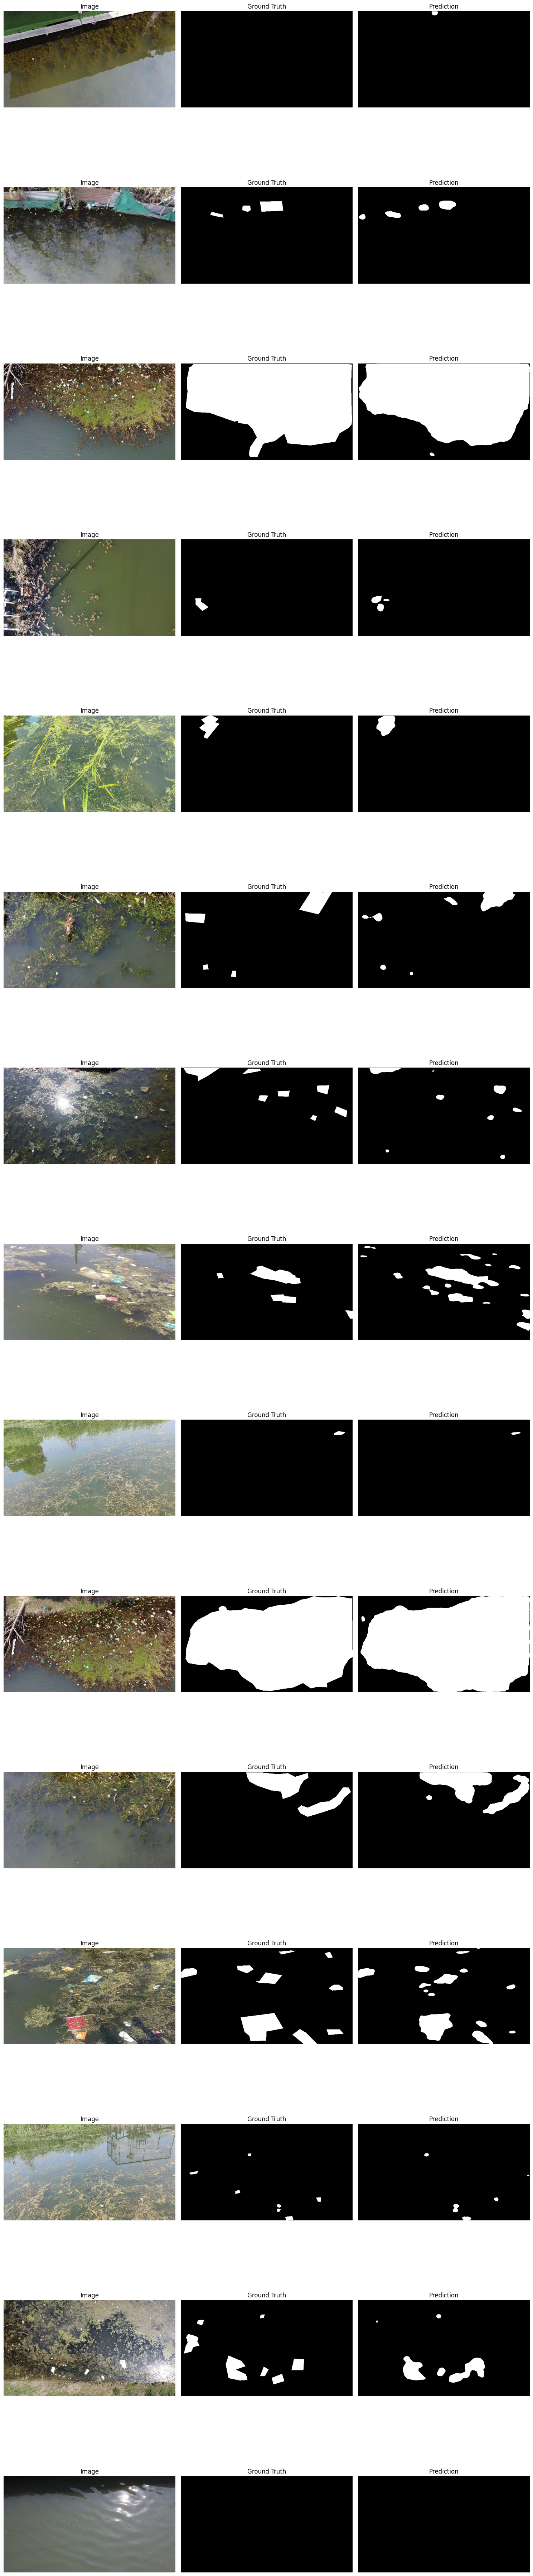

In [ ]:
show_predictions(model, test_dataset, DEVICE, threshold=best_threshold, num_samples=15)